# Preprocessing

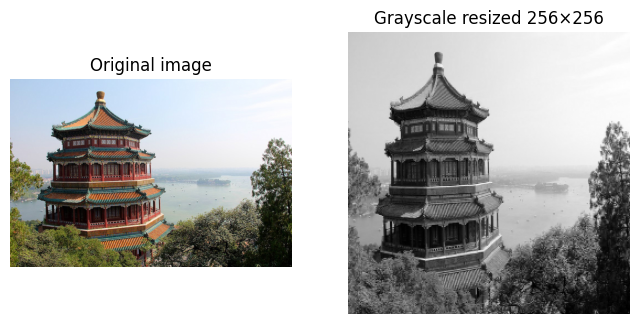

In [1]:
from sklearn.datasets import load_sample_image
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.transform import resize


china = load_sample_image("china.jpg") / 255.0
# print(china.shape) = 427 x 640
# The image is in 427x640 so rize it
china_gray = rgb2gray(china)

# Resize
china_resized = resize(china_gray, (256, 256), anti_aliasing=True)

# Side by side comparison
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(china, cmap='gray')
ax[0].set_title("Original image")
ax[0].axis("off")

ax[1].imshow(china_resized, cmap='gray')
ax[1].set_title("Grayscale resized 256×256")
ax[1].axis("off")

plt.show()

# Blockwise SVD function

In [2]:
blocks = china_resized.reshape(32, 8, 32, 8).swapaxes(1, 2)

def Compress_block(block, k):
    # Convert block to float
    A = np.array(block, dtype=np.float64)
    #SVD
    U, S, VT = np.linalg.svd(A, full_matrices=False)
    #top-k Singular values
    Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

    return Ak

In [3]:
def reconstruct_image_from_blocks(blocks):
    rows = []
    for i in range(blocks.shape[0]):
        row = np.hstack(blocks[i])
        rows.append(row)
    return np.vstack(rows)


# Compression Analysis

In [4]:
reconstruction_errors = []
compressed_images = {}
compression_ratios = {}

for k in range(1, 9):
    compressed_blocks = np.zeros_like(blocks)

    # compress each block
    for i in range(32):
        for j in range(32):
            compressed_blocks[i, j] = Compress_block(blocks[i, j], k)

    # reconstruct full image
    reconstructed = reconstruct_image_from_blocks(compressed_blocks)
    compressed_images[k] = reconstructed

    # compute compression ratio
    ratio = 64 / (17 * k) # (k * (8 + 8 + 1)) = 17*k
    compression_ratios[k] = ratio

    # compute Frobenius norm
    error = np.linalg.norm(china_resized - reconstructed, ord='fro') 
    reconstruction_errors.append(error)
    # Save
    plt.imsave(f"reconstructed_k{k}.png", reconstructed, cmap='gray')

# Visualization

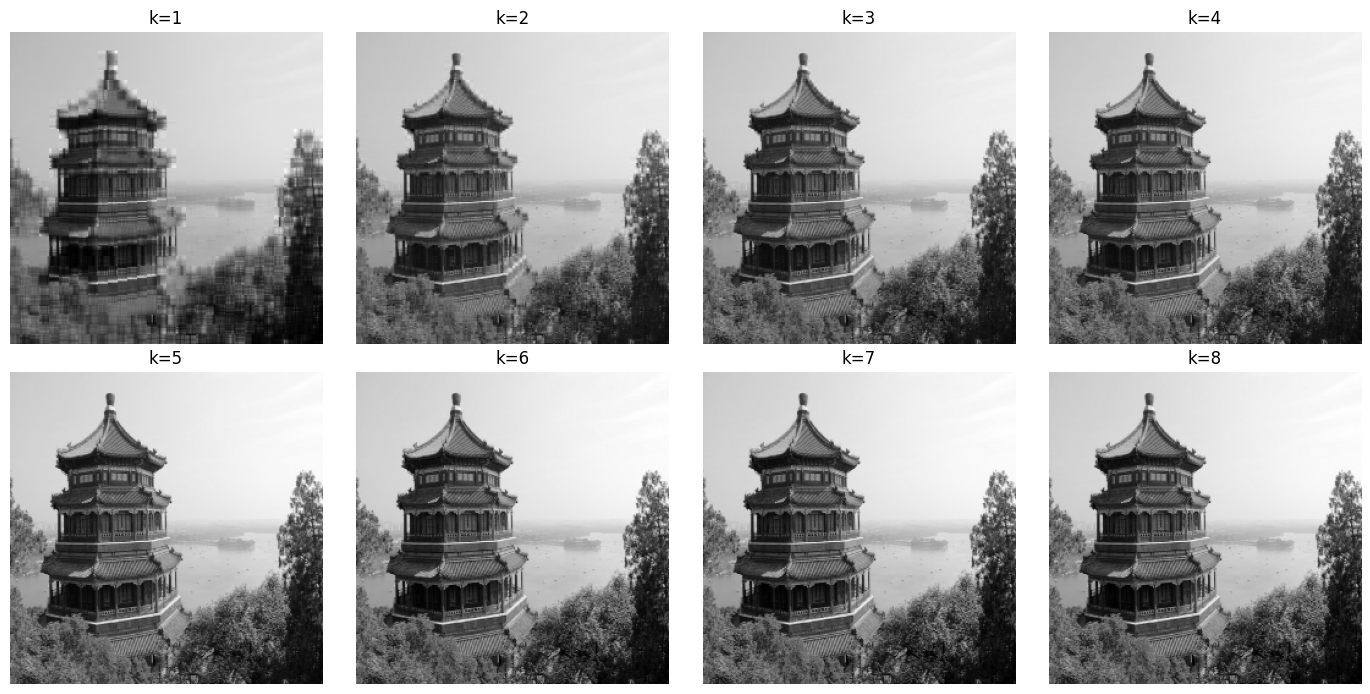

In [5]:
plt.figure(figsize=(14, 7))
for k in range(1, 9):
    compressed_blocks = np.zeros_like(blocks)

    # compress each block
    for i in range(32):
        for j in range(32):
            compressed_blocks[i, j] = Compress_block(blocks[i, j], k)

    # reconstruct full image
    reconstructed = reconstruct_image_from_blocks(compressed_blocks)
    # subplot position (1–8)
    plt.subplot(2, 4, k)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f'k={k}')
    plt.axis('off')

plt.tight_layout()
plt.show() 

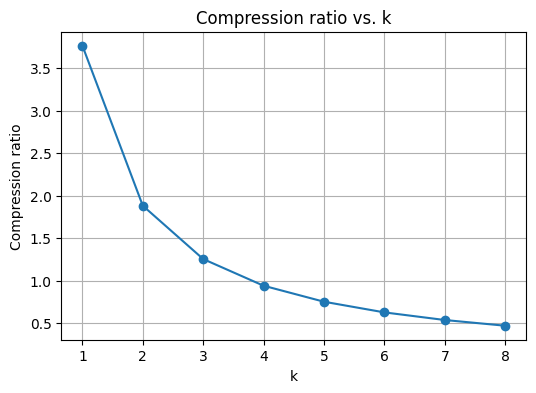

In [6]:
# Since I used a dictionary for storing compression ratios, I need to extract the keys and values for plotting. 
ks = list(compression_ratios.keys())
ratios = list(compression_ratios.values())

plt.figure(figsize=(6,4))
plt.plot(ks, ratios, marker='o')
plt.xlabel("k")
plt.ylabel("Compression ratio")
plt.title("Compression ratio vs. k")
plt.grid(True)
plt.show()

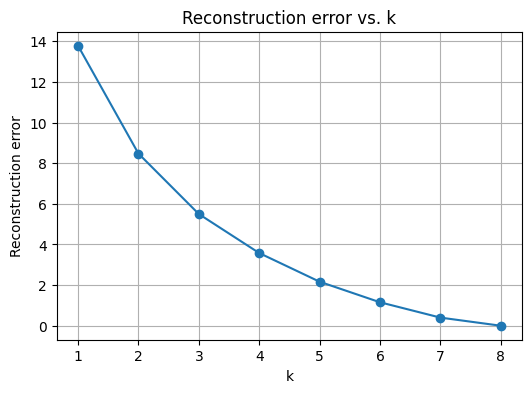

In [7]:
plt.figure(figsize=(6,4))
plt.plot(range(1,9), reconstruction_errors, marker='o')
plt.xlabel("k")
plt.ylabel("Reconstruction error")
plt.title("Reconstruction error vs. k")
plt.grid(True)
plt.show()
